In [ ]:
# 1. Setting up the environment and importing libraries
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from torch.distributions import Categorical
import time

if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_

In [ ]:
# 2. Preparing the environment
class QuantumHypercubeEnv(gym.Env):
    def __init__(self, n_qubits=6):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_states = 2 ** n_qubits
        self.observation_space = spaces.Discrete(self.n_states)
        self.action_space = spaces.Discrete(self.n_qubits)
        self.target_state = self.n_states - 1 
        self.max_steps = 40
        self.current_state = 0
        self.current_step = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_state = 0
        self.current_step = 0
        return self.current_state, {}

    def step(self, action):
        self.current_step += 1
        # if np.random.rand() < 0.15:
        #     action = np.random.randint(self.action_space.n)
        
        self.current_state = self.current_state ^ (1 << action)
        
        terminated = False
        truncated = False
        reward = -0.1 

        if self.current_state == self.target_state:
            reward = 10.0
            terminated = True
        elif self.current_step >= self.max_steps:
            truncated = True

        return self.current_state, reward, terminated, truncated, {}

env = QuantumHypercubeEnv(n_qubits=6)
n_states = env.observation_space.n
n_actions = env.action_space.n

def get_state_vec(state):
    return torch.tensor([int(b) for b in format(state, '06b')], dtype=torch.float32)

In [ ]:
# 3. Definition of the classical model
class ClassicalPG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 6),
            nn.Softmax(dim=-1)
        )
    def forward(self, x): return self.net(x)

In [ ]:
# 4. Definition of a quantum model
dev = qml.device("default.qubit", wires=6)

@qml.qnode(dev, interface="torch", diff_method="backprop")
def qpg_circuit(inputs, weights):
    qml.AngleEmbedding(inputs * np.pi, wires=range(6))
    qml.StronglyEntanglingLayers(weights, wires=range(6))
    return [qml.expval(qml.PauliZ(i)) for i in range(6)]

class QuantumPG(nn.Module):
    def __init__(self, n_layers=6):
        super().__init__()
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, 6, 3))
        self.logits_scale = nn.Parameter(torch.tensor(5.0))
        
    def forward(self, x):
        res = qpg_circuit(x, self.weights)
        logits = torch.stack(res).float() * self.logits_scale
        
        return F.softmax(logits, dim=-1)

In [ ]:
# 5. Standardised training function
# import time

def train_pg(model_type="classical", episodes=800):
    # start_time = time.time()
    model = ClassicalPG() if model_type == "classical" else QuantumPG()
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

    optimizer = optim.Adam(model.parameters(), lr=0.01)
    history = {'rewards': [], 'success': []}
    history = {'rewards': [], 'success': [], 'param_count': param_count}
    
    for ep in range(episodes):
        state, _ = env.reset()
        log_probs = []
        rewards = []
        is_success = 0
        
        # ep_start_time = time.time()

        for _ in range(40):
            state_vec = get_state_vec(state)
            probs = model(state_vec)
            m = Categorical(probs)
            action = m.sample()
            
            log_probs.append(m.log_prob(action))
            state, reward, terminated, truncated, _ = env.step(action.item())
            rewards.append(reward)
            
            if terminated and reward > 0:
                is_success = 1
            if terminated or truncated: break

        # ep_end_time = time.time()  
        discounted_rewards = []
        R = 0
        for r in reversed(rewards):
            R = r + 0.95 * R
            discounted_rewards.insert(0, R)
        
        # update_start_time = time.time()
        discounted_rewards = torch.tensor(discounted_rewards)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)
        
        policy_loss = []
        for log_prob, reward in zip(log_probs, discounted_rewards):
            policy_loss.append(-log_prob * reward)
            
        optimizer.zero_grad()
        sum(policy_loss).backward()
        optimizer.step()
        
        history['rewards'].append(sum(rewards))
        history['success'].append(is_success)

        # update_end_time = time.time()
        
        # print(f"model type: {model_type}, ep_start: {ep_start_time}, ep_end: {ep_end_time}, update_start: {update_start_time}, update_end: {update_end_time}")

        if (ep + 1) % 10 == 0:
            avg_reward_last_10 = np.mean(history['rewards'][-10:])
            success_rate_last_10 = np.mean(history['success'][-10:]) * 100
            print(f"Model: {model_type.upper()} | Episode: {ep + 1}/{episodes} | "
                  f"Avg Reward (last 10): {avg_reward_last_10:.2f} | "
                  f"Success Rate (last 10): {success_rate_last_10:.1f}%")
    # end_time = time.time()
    # history['training_time'] = end_time - start_time
        
    return history

In [ ]:
# 6. Training classic models
print("Training a classic PG...")
c_history = train_pg("classical", 800)
# 7. Training quantum models
print("Training the Quantum QPG...")
q_history = train_pg("quantum", 800)

Training a classic PG...
Model: CLASSICAL | Episode: 10/800 | Avg Reward (last 10): 1.63 | Success Rate (last 10): 50.0%
Model: CLASSICAL | Episode: 20/800 | Avg Reward (last 10): -0.49 | Success Rate (last 10): 30.0%
Model: CLASSICAL | Episode: 30/800 | Avg Reward (last 10): 2.07 | Success Rate (last 10): 50.0%
Model: CLASSICAL | Episode: 40/800 | Avg Reward (last 10): -1.72 | Success Rate (last 10): 20.0%
Model: CLASSICAL | Episode: 50/800 | Avg Reward (last 10): 1.73 | Success Rate (last 10): 50.0%
Model: CLASSICAL | Episode: 60/800 | Avg Reward (last 10): 2.90 | Success Rate (last 10): 60.0%
Model: CLASSICAL | Episode: 70/800 | Avg Reward (last 10): -1.68 | Success Rate (last 10): 20.0%
Model: CLASSICAL | Episode: 80/800 | Avg Reward (last 10): -1.66 | Success Rate (last 10): 20.0%
Model: CLASSICAL | Episode: 90/800 | Avg Reward (last 10): -0.57 | Success Rate (last 10): 30.0%
Model: CLASSICAL | Episode: 100/800 | Avg Reward (last 10): -0.47 | Success Rate (last 10): 30.0%
Model: C

In [ ]:
# 8. Model evaluation
def evaluate_model(history, model_name, window=50):
    recent_rewards = history['rewards'][-window:]
    recent_success = history['success'][-window:]

    avg_reward = np.mean(recent_rewards)
    win_rate = np.mean(recent_success)
    stability = np.std(recent_rewards) 
    training_time = history.get('training_time', 0.0)
    param_count = history.get('param_count', 'Unknown')

    print(f"--- {model_name} Evaluation results ---")
    print(f"Number of model parameters : {param_count}")
    print(f"Final average return : {avg_reward:.4f}")
    print(f"Overall win rate     : {win_rate:.4f}")
    print(f"Convergence stability   : {stability:.4f}")
    print(f"Total training time  : {training_time:.4f} seconds")
    print("-" * 35)
    
    return avg_reward, win_rate, stability

print("\n========== Quantitative evaluation of model performance ==========")
c_avg_reward, c_win_rate, c_stability = evaluate_model(c_history, "Classical PG")
q_avg_reward, q_win_rate, q_stability = evaluate_model(q_history, "Quantum QPG")



========== Quantitative evaluation of model performance ==========
--- Classical PG Evaluation results ---
Number of model parameters : 422
Final average return : 9.4440
Overall win rate     : 1.0000
Convergence stability   : 0.1061
Total training time  : 6.2230 seconds
-----------------------------------
--- Quantum QPG Evaluation results ---
Number of model parameters : 109
Final average return : 6.9360
Overall win rate     : 0.8800
Convergence stability   : 4.1365
Total training time  : 2150.6730 seconds
-----------------------------------


Classical PG Params: 422
Quantum QPG Params: 109


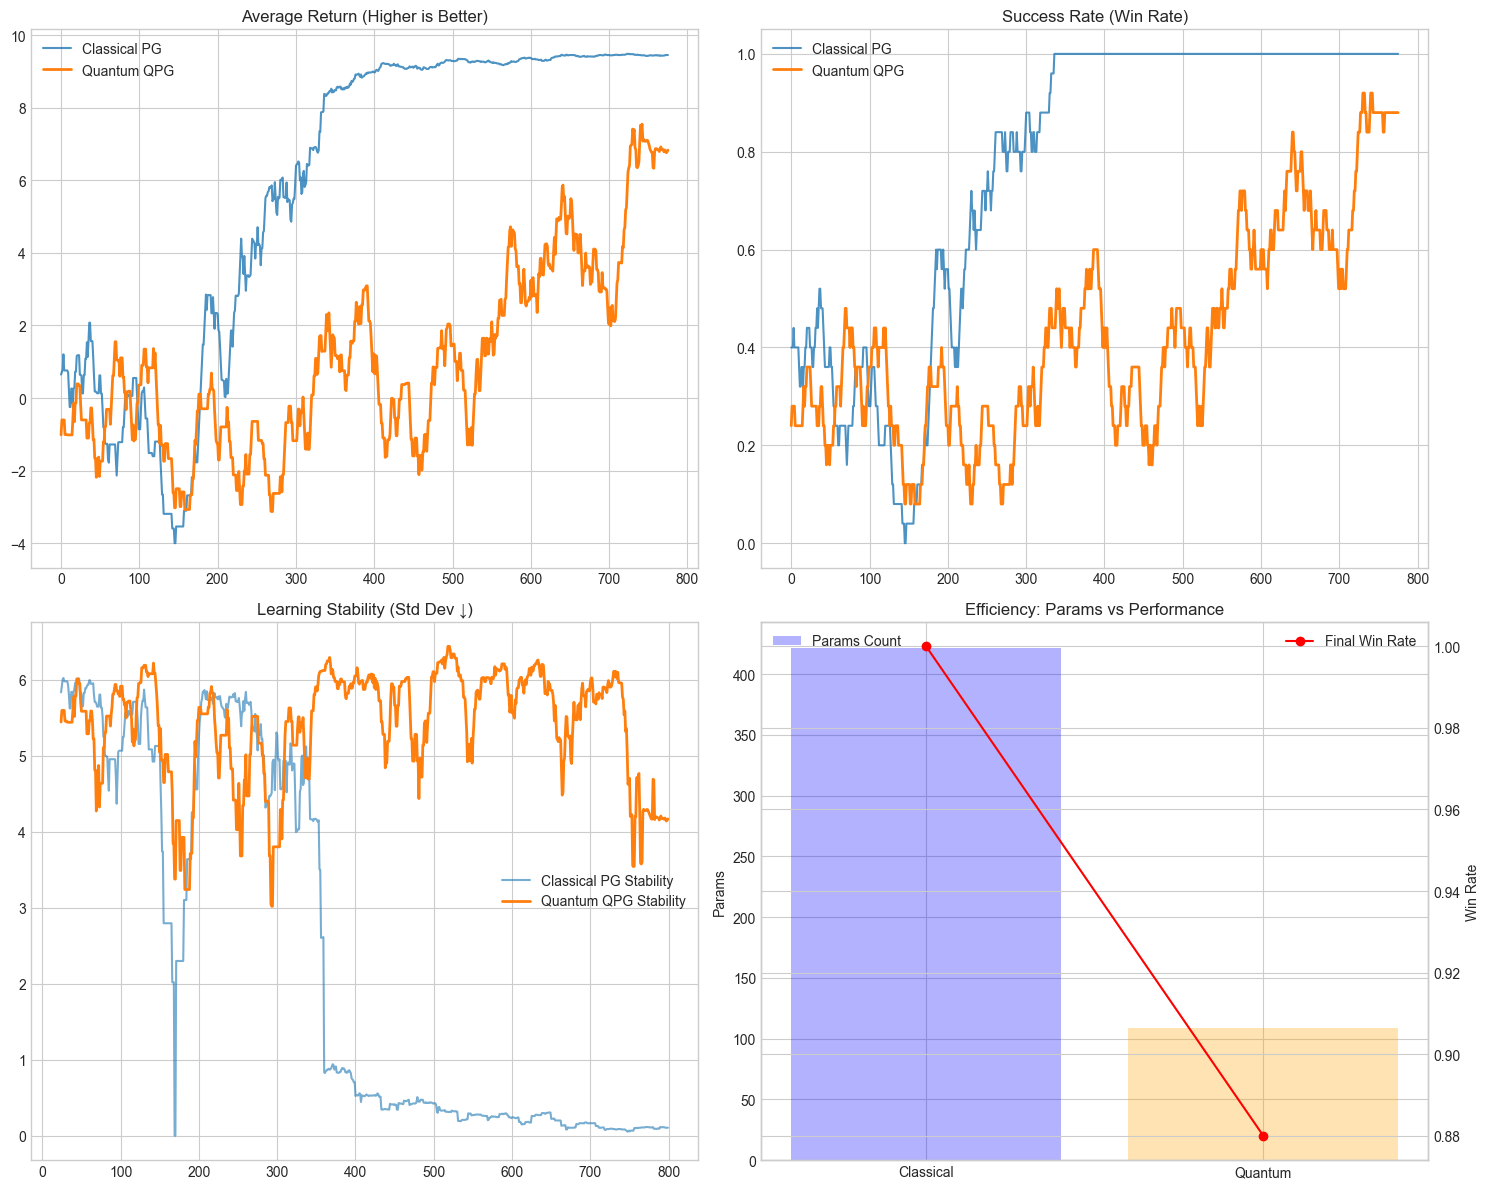

In [ ]:
# 9. Visual comparative analysis
def smooth(data, window=25):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# 1. Comparison of average returns
axs[0,0].plot(smooth(c_history['rewards']), label='Classical PG', alpha=0.8)
axs[0,0].plot(smooth(q_history['rewards']), label='Quantum QPG', linewidth=2)
axs[0,0].set_title("Average Return (Higher is Better)")
axs[0,0].legend()

# 2. Win Rate Comparison
axs[0,1].plot(smooth(c_history['success']), label='Classical PG', alpha=0.8)
axs[0,1].plot(smooth(q_history['success']), label='Quantum QPG', linewidth=2)
axs[0,1].set_title("Success Rate (Win Rate)")
axs[0,1].legend()

# 3. Learning stability (sliding standard deviation)
c_std = pd.Series(c_history['rewards']).rolling(25).std()
q_std = pd.Series(q_history['rewards']).rolling(25).std()
axs[1,0].plot(c_std, label='Classical PG Stability', alpha=0.6)
axs[1,0].plot(q_std, label='Quantum QPG Stability', linewidth=2)
axs[1,0].set_title("Learning Stability (Std Dev ↓)")
axs[1,0].legend()

# 4. Parameter efficiency vs. final win rate
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
c_params_count = c_history['param_count']
q_params_count = q_history['param_count']

print(f"Classical PG Params: {c_params_count}") 
print(f"Quantum QPG Params: {q_params_count}") 
labels = ['Classical', 'Quantum']
params = [c_params_count, q_params_count]
final_win = [np.mean(c_history['success'][-50:]), np.mean(q_history['success'][-50:])]
axs[1,1].bar(labels, params, color=['blue', 'orange'], alpha=0.3, label='Params Count')
axs[1,1].set_ylabel('Params')
ax2 = axs[1,1].twinx()
ax2.plot(labels, final_win, 'ro-', label='Final Win Rate')
ax2.set_ylabel('Win Rate')
axs[1,1].set_title("Efficiency: Params vs Performance")
axs[1,1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()